# Customer Churn Prediction & ROI-Backend Retention Playbook

## Project Overview
This notebook implements machine learning models to predict customer churn in the telecom industry.

**Objectives:**
- Analyze customer behavior patterns
- Build predictive models for churn
- Identify key factors driving churn
- Provide actionable retention strategies


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [122]:
df = pd.read_csv('Telco-Customer-Churn.csv') 

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (7043, 21)
Rows: 7043, Columns: 21


In [123]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [124]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

In [125]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [126]:
# Check for missing values
print("Missing Values Count:")
print(df.isnull().sum())


Missing Values Count:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


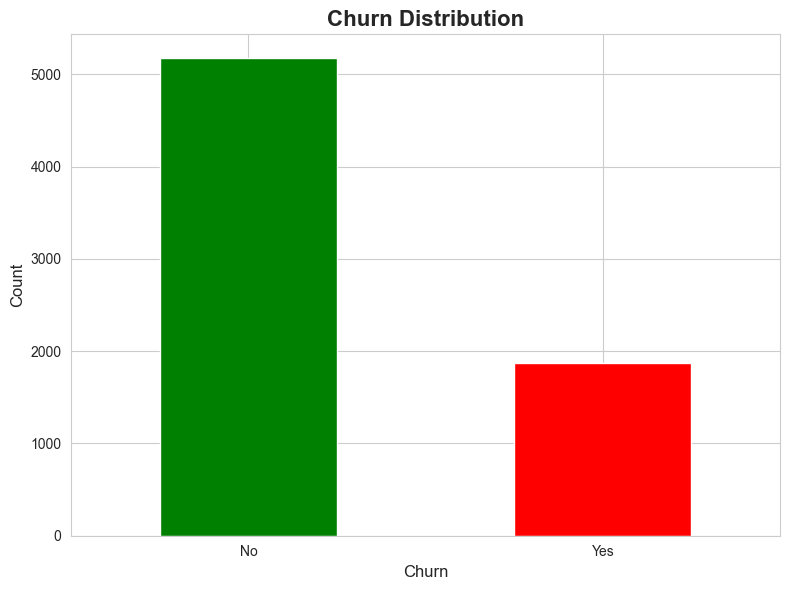

In [127]:
# Analyze churn distribution
print("Churn Distribution:")
print(df['Churn'].value_counts())

print("\n" + "="*50)
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
print("Churn Percentage:")
print(churn_percentage)

# Visualize churn distribution
plt.figure(figsize=(8, 6))
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [128]:
# Strip spaces and replace empty strings with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Check if any NaN appeared (these were the blank spaces)
print("Blank entries found:", df['TotalCharges'].isna().sum())

# Convert safely to float
df['TotalCharges'] = df['TotalCharges'].astype('float64')
df['MonthlyCharges'] = df['MonthlyCharges'].astype('float64')

# Optional: if you want to handle those NaNs (e.g., set them to 0 or median)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify
print(df[['MonthlyCharges', 'TotalCharges']].dtypes)


Blank entries found: 11
MonthlyCharges    float64
TotalCharges      float64
dtype: object


In [129]:
# Fill NaN values in TotalCharges with median
median_total = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total)

# Verify
print(f"Median value used for filling: {median_total}")
print(df[['MonthlyCharges', 'TotalCharges']].dtypes)
print("Remaining NaN after fill:", df['TotalCharges'].isna().sum())

Median value used for filling: 1394.55
MonthlyCharges    float64
TotalCharges      float64
dtype: object
Remaining NaN after fill: 0


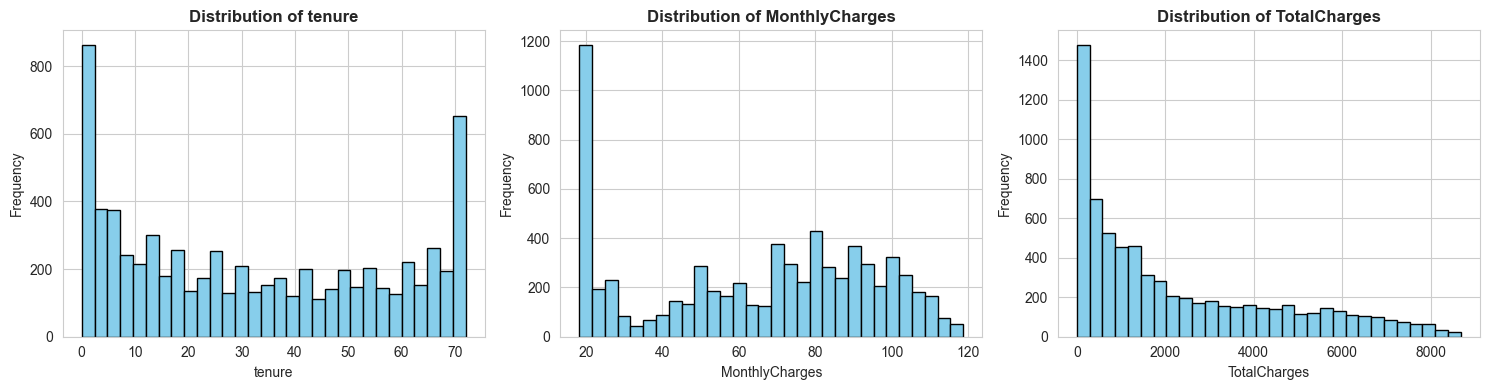

In [130]:
# Analyze numerical features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

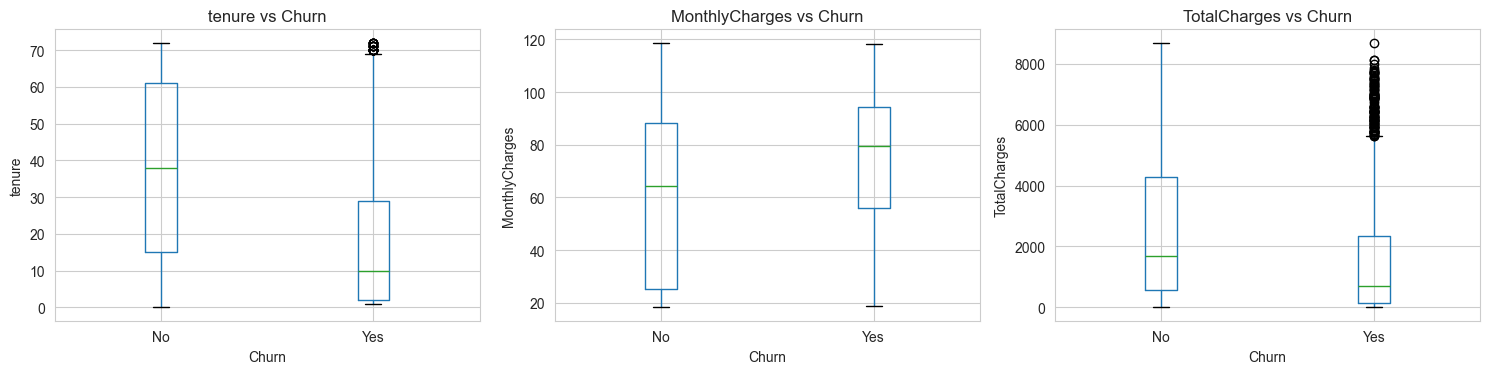

In [131]:
# Analyze numerical features against churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='Churn', ax=axes[idx])
    axes[idx].set_title(f'{col} vs Churn')
    axes[idx].set_xlabel('Churn')
    axes[idx].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [133]:
# List all categorical columns
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

# Display unique values for each categorical column
for col in categorical_cols:
    print(f"\n{col} - Unique Values:")
    print(df[col].value_counts())
    print("-" * 40)


gender - Unique Values:
gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------------------------

SeniorCitizen - Unique Values:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
----------------------------------------

Partner - Unique Values:
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------------

Dependents - Unique Values:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------------

PhoneService - Unique Values:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
----------------------------------------

MultipleLines - Unique Values:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------------------------

InternetService - Unique Values:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
-----------------------

In [134]:
# Calculate churn rate for key categorical features
key_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                'Contract', 'InternetService', 'PaymentMethod']

for feature in key_features:
    churn_rate = df.groupby(feature)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
    print(f"\nChurn Rate by {feature}:")
    print(churn_rate.sort_values(ascending=False))
    print("-" * 50)


Churn Rate by gender:
gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64
--------------------------------------------------

Churn Rate by SeniorCitizen:
SeniorCitizen
1    41.681261
0    23.606168
Name: Churn, dtype: float64
--------------------------------------------------

Churn Rate by Partner:
Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64
--------------------------------------------------

Churn Rate by Dependents:
Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64
--------------------------------------------------

Churn Rate by Contract:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64
--------------------------------------------------

Churn Rate by InternetService:
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64
--------------------------------------------------

Ch

In [135]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



## Feature Engineering

In [136]:
# Create new features
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], 
                            labels=['0-1 Year', '1-2 Years', '2-4 Years', '4+ Years'])

print("New features created:")
print(df[['tenure', 'TenureGroup', 'ChargesPerMonth']].head(10))

New features created:
   tenure TenureGroup  ChargesPerMonth
0       1    0-1 Year        14.925000
1      34   2-4 Years        53.985714
2       2    0-1 Year        36.050000
3      45   2-4 Years        40.016304
4       2    0-1 Year        50.550000
5       8    0-1 Year        91.166667
6      22   1-2 Years        84.756522
7      10    0-1 Year        27.445455
8      28   2-4 Years       105.036207
9      62    4+ Years        55.364286


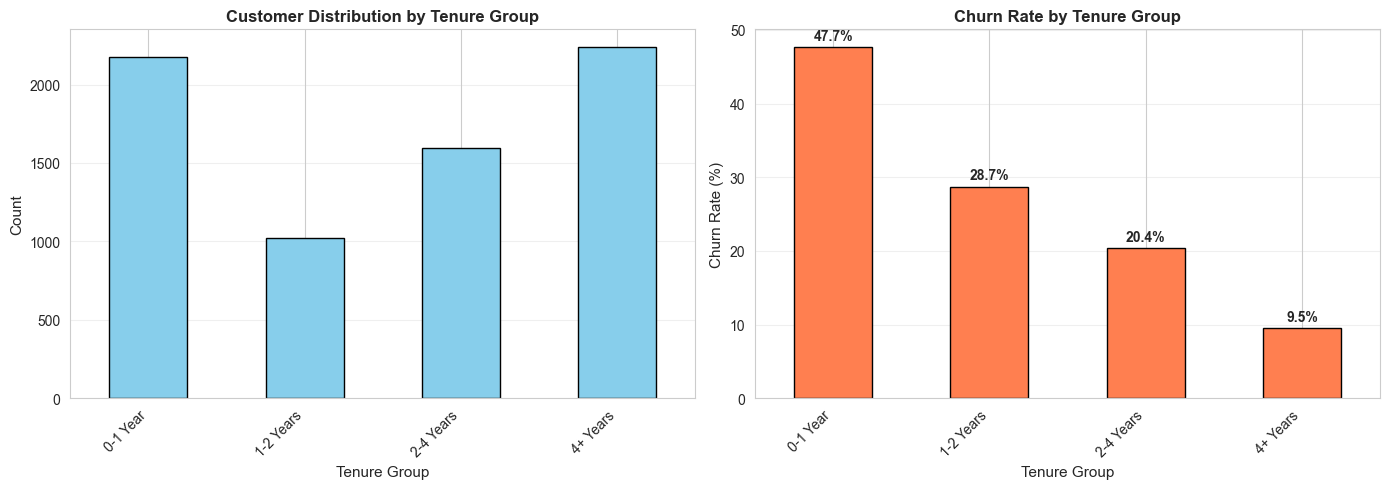

In [137]:
# Visualize tenure groups and churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure group distribution
df['TenureGroup'].value_counts().sort_index().plot(kind='bar', ax=axes[0], 
                                                     color='skyblue', edgecolor='black')
axes[0].set_title('Customer Distribution by Tenure Group', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Tenure Group', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Compute churn rate by tenure group (exclude missing TenureGroup)
tenure_churn = (
    df.dropna(subset=['TenureGroup'])
      .groupby('TenureGroup')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_index()
)

# If TenureGroup categories are known, ensure consistent order (optional)
ordered_groups = ['0-1 Year', '1-2 Years', '2-4 Years', '4+ Years']
tenure_churn = tenure_churn.reindex([g for g in ordered_groups if g in tenure_churn.index])

# If there is no data to plot, show a message instead of erroring
if tenure_churn.empty:
    axes[1].text(0.5, 0.5, 'No TenureGroup / Churn data available', ha='center', va='center')
    axes[1].set_axis_off()
else:
    # Churn rate by tenure group
    tenure_churn.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Churn Rate by Tenure Group', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Tenure Group', fontsize=11)
    axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3)

    # Add percentage labels
    for i, v in enumerate(tenure_churn):
        axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [138]:
print("="*60)
print("PREPARING DATA FOR MACHINE LEARNING")
print("="*60)

df_ml = df.drop(['customerID', 'TenureGroup','ChargesPerMonth'], axis=1, errors='ignore')


X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

print(f"\n✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")

print("\n" + "="*60)
print("TARGET DISTRIBUTION")
print("="*60)
print(y.value_counts())
print(f"\nChurn Rate: {(y == 'Yes').sum() / len(y) * 100:.2f}%")

PREPARING DATA FOR MACHINE LEARNING

✅ Features shape: (7043, 19)
✅ Target shape: (7043,)

TARGET DISTRIBUTION
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


In [139]:
print(y.unique())


['No' 'Yes']


In [140]:
# Now map to 0 and 1
y = y.map({'Yes': 1, 'No': 0})

In [141]:
print(y.unique())


[0 1]


In [142]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

print("\n" + "="*60)
print("TRAINING SET TARGET DISTRIBUTION (BEFORE SMOTE-ENN)")
print("="*60)
print(y_train.value_counts())
print(f"Class 0 (No Churn): {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.2f}%)")
print(f"Class 1 (Churn): {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.2f}%)")

print("\n" + "="*60)
print("TEST SET TARGET DISTRIBUTION")
print("="*60)
print(y_test.value_counts())
print(f"Class 0 (No Churn): {(y_test == 0).sum()} ({(y_test == 0).sum() / len(y_test) * 100:.2f}%)")
print(f"Class 1 (Churn): {(y_test == 1).sum()} ({(y_test == 1).sum() / len(y_test) * 100:.2f}%)")

TRAIN-TEST SPLIT
Training set size: (5634, 19)
Test set size: (1409, 19)

TRAINING SET TARGET DISTRIBUTION (BEFORE SMOTE-ENN)
Churn
0    4139
1    1495
Name: count, dtype: int64
Class 0 (No Churn): 4139 (73.46%)
Class 1 (Churn): 1495 (26.54%)

TEST SET TARGET DISTRIBUTION
Churn
0    1035
1     374
Name: count, dtype: int64
Class 0 (No Churn): 1035 (73.46%)
Class 1 (Churn): 374 (26.54%)


In [143]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining set target distribution:")
print(y_train.value_counts())
print("\nTest set target distribution:")
print(y_test.value_counts())

Training set size: (5634, 19)
Test set size: (1409, 19)

Training set target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Test set target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


In [ ]:
import joblib
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "D:/Major Project/feature_columns.pkl")

print("feature_columns.pkl saved successfully!")


feature_columns.pkl saved successfully!


## Feature Scaling

In [145]:
from sklearn.preprocessing import LabelEncoder

# List of categorical columns (from your summary)
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])   # notice: transform only!
    label_encoders[col] = le


In [146]:
import joblib

# Save all label encoders together
joblib.dump(label_encoders, "label_encoders.pkl")

print("All label encoders saved successfully!")


All label encoders saved successfully!


In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [148]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully as scaler.pkl")

Scaler saved successfully as scaler.pkl


In [149]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [150]:
# Import SMOTE-ENN
from imblearn.combine import SMOTEENN
from collections import Counter

print("="*60)
print("IMPORTING SMOTE-ENN")
print("="*60)
print("SMOTE-ENN imported successfully from imbalanced-learn library!")


IMPORTING SMOTE-ENN
SMOTE-ENN imported successfully from imbalanced-learn library!


In [151]:
# Apply SMOTE-ENN
print("="*60)
print("APPLYING SMOTE-ENN")
print("="*60)

# Initialize SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)

# Store original distribution
print("BEFORE SMOTE-ENN:")
print(f"Training samples: {len(X_train_scaled)}")
print(f"Class distribution: {Counter(y_train)}")
print(f"  Class 0 (No Churn): {(y_train == 0).sum()}")
print(f"  Class 1 (Churn): {(y_train == 1).sum()}")
print(f"Imbalance ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

# Apply SMOTE-ENN to training data only
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled_df, y_train)

print("\n" + "="*60)
print("AFTER SMOTE-ENN:")
print("="*60)
print(f"Training samples: {len(X_train_resampled)}")
print(f"Class distribution: {Counter(y_train_resampled)}")
print(f"  Class 0 (No Churn): {(y_train_resampled == 0).sum()}")
print(f"  Class 1 (Churn): {(y_train_resampled == 1).sum()}")
print(f"Imbalance ratio: {(y_train_resampled == 0).sum() / (y_train_resampled == 1).sum():.2f}:1")

print("\n SMOTE-ENN applied successfully!")
print(f" Samples added: {len(X_train_resampled) - len(X_train_scaled)}")

APPLYING SMOTE-ENN
BEFORE SMOTE-ENN:
Training samples: 5634
Class distribution: Counter({0: 4139, 1: 1495})
  Class 0 (No Churn): 4139
  Class 1 (Churn): 1495
Imbalance ratio: 2.77:1

AFTER SMOTE-ENN:
Training samples: 5015
Class distribution: Counter({1: 2787, 0: 2228})
  Class 0 (No Churn): 2228
  Class 1 (Churn): 2787
Imbalance ratio: 0.80:1

 SMOTE-ENN applied successfully!
 Samples added: -619


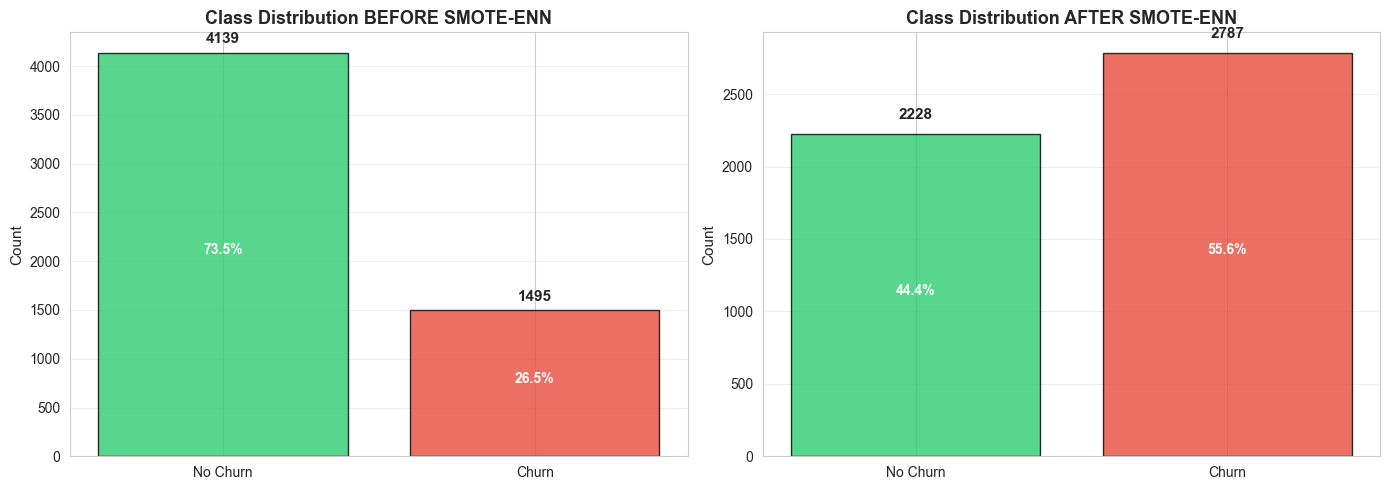

VISUALIZATION COMPLETED


In [152]:
# Visualize class distribution before and after SMOTE-ENN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE-ENN
before_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(['No Churn', 'Churn'], before_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[0].set_title('Class Distribution BEFORE SMOTE-ENN', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=11)
    axes[0].text(i, v/2, f'{v/len(y_train)*100:.1f}%', ha='center', 
                fontweight='bold', fontsize=10, color='white')

# After SMOTE-ENN
after_counts = pd.Series(y_train_resampled).value_counts().sort_index()
axes[1].bar(['No Churn', 'Churn'], after_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[1].set_title('Class Distribution AFTER SMOTE-ENN', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=11)
    axes[1].text(i, v/2, f'{v/len(y_train_resampled)*100:.1f}%', ha='center', 
                fontweight='bold', fontsize=10, color='white')

plt.tight_layout()
plt.show()

print("="*60)
print("VISUALIZATION COMPLETED")
print("="*60)

In [153]:
# Summary of SMOTE-ENN impact
print("="*60)
print("SMOTE-ENN IMPACT SUMMARY")
print("="*60)

original_total = len(X_train_scaled_df)
resampled_total = len(X_train_resampled)
samples_added = resampled_total - original_total

original_minority = (y_train == 1).sum()
resampled_minority = (y_train_resampled == 1).sum()
minority_increase = resampled_minority - original_minority

original_majority = (y_train == 0).sum()
resampled_majority = (y_train_resampled == 0).sum()
majority_decrease = original_majority - resampled_majority

print(f"\n Total Samples:")
print(f"   Before: {original_total}")
print(f"   After:  {resampled_total}")
print(f"   Change: +{samples_added} ({samples_added/original_total*100:.2f}%)")

print(f"\n Minority Class (Churn):")
print(f"   Before: {original_minority}")
print(f"   After:  {resampled_minority}")
print(f"   Change: +{minority_increase} ({minority_increase/original_minority*100:.2f}%)")

print(f"\n Majority Class (No Churn):")
print(f"   Before: {original_majority}")
print(f"   After:  {resampled_majority}")
print(f"   Change: -{majority_decrease} ({-majority_decrease/original_majority*100:.2f}%)")

print(f"\n Class Balance:")
print(f"   Before: {original_majority/original_minority:.2f}:1")
print(f"   After:  {resampled_majority/resampled_minority:.2f}:1")

print("\n Dataset is now balanced and ready for model training!")

SMOTE-ENN IMPACT SUMMARY

 Total Samples:
   Before: 5634
   After:  5015
   Change: +-619 (-10.99%)

 Minority Class (Churn):
   Before: 1495
   After:  2787
   Change: +1292 (86.42%)

 Majority Class (No Churn):
   Before: 4139
   After:  2228
   Change: -1911 (-46.17%)

 Class Balance:
   Before: 2.77:1
   After:  0.80:1

 Dataset is now balanced and ready for model training!


In [154]:
from xgboost import XGBClassifier

# Define all models
print("="*60)
print("DEFINING MACHINE LEARNING MODELS")
print("="*60)

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5),
    "XGBoost": XGBClassifier(random_state=42, n_estimators=100, max_depth=5, eval_metric='logloss')
}

print(f"Total models to train: {len(models)}")
for idx, model_name in enumerate(models.keys(), 1):
    print(f"{idx}. {model_name}")
    
print("\n All models defined successfully!")

DEFINING MACHINE LEARNING MODELS
Total models to train: 5
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

 All models defined successfully!


In [155]:
# Train and evaluate all models
print("="*80)
print("TRAINING AND EVALUATING ALL MODELS")
print("="*80)

# Store results for comparison
results = []

for i in range(len(list(models))):
    model_name = list(models.keys())[i]
    model = list(models.values())[i]
    
    print("\n" + "="*80)
    print(f"MODEL {i+1}: {model_name}")
    print("="*80)
    
    # Train model on resampled training data
    print("Training model...")
    model.fit(X_train_resampled, y_train_resampled)
    
    # Make predictions
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Get prediction probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_train_pred_proba = model.predict_proba(X_train_resampled)[:, 1]
        y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_train_pred_proba = y_train_pred
        y_test_pred_proba = y_test_pred
    
    # Training set performance
    model_train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
    model_train_f1 = f1_score(y_train_resampled, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train_resampled, y_train_pred)
    model_train_recall = recall_score(y_train_resampled, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train_resampled, y_train_pred_proba)
    
    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred_proba)
    
    # Print results
    print("\n Model Performance for Training Set")
    print("-" * 40)
    print(f"  - Accuracy:  {model_train_accuracy:.4f}")
    print(f"  - F1 Score:  {model_train_f1:.4f}")
    print(f"  - Precision: {model_train_precision:.4f}")
    print(f"  - Recall:    {model_train_recall:.4f}")
    print(f"  - ROC-AUC:   {model_train_rocauc_score:.4f}")
    
    print("\n Model Performance for Test Set")
    print("-" * 40)
    print(f"  - Accuracy:  {model_test_accuracy:.4f}")
    print(f"  - F1 Score:  {model_test_f1:.4f}")
    print(f"  - Precision: {model_test_precision:.4f}")
    print(f"  - Recall:    {model_test_recall:.4f}")
    print(f"  - ROC-AUC:   {model_test_rocauc_score:.4f}")
    
    # Store results
    results.append({
        'Model': model_name,
        'Train_Accuracy': model_train_accuracy,
        'Train_F1': model_train_f1,
        'Train_Precision': model_train_precision,
        'Train_Recall': model_train_recall,
        'Train_ROC_AUC': model_train_rocauc_score,
        'Test_Accuracy': model_test_accuracy,
        'Test_F1': model_test_f1,
        'Test_Precision': model_test_precision,
        'Test_Recall': model_test_recall,
        'Test_ROC_AUC': model_test_rocauc_score
    })
    
    print("="*80)

print("\n All models trained and evaluated successfully!")

TRAINING AND EVALUATING ALL MODELS

MODEL 1: Logistic Regression
Training model...

 Model Performance for Training Set
----------------------------------------
  - Accuracy:  0.9107
  - F1 Score:  0.9106
  - Precision: 0.9146
  - Recall:    0.9257
  - ROC-AUC:   0.9711

 Model Performance for Test Set
----------------------------------------
  - Accuracy:  0.6984
  - F1 Score:  0.7160
  - Precision: 0.4634
  - Recall:    0.8636
  - ROC-AUC:   0.8347

MODEL 2: Decision Tree
Training model...

 Model Performance for Training Set
----------------------------------------
  - Accuracy:  0.9848
  - F1 Score:  0.9848
  - Precision: 0.9815
  - Recall:    0.9914
  - ROC-AUC:   0.9986

 Model Performance for Test Set
----------------------------------------
  - Accuracy:  0.7126
  - F1 Score:  0.7286
  - Precision: 0.4746
  - Recall:    0.7754
  - ROC-AUC:   0.7534

MODEL 3: Random Forest
Training model...

 Model Performance for Training Set
----------------------------------------
  - Accurac

In [156]:
# Create comparison dataframe
results_df = pd.DataFrame(results)

print("="*80)
print("MODEL COMPARISON SUMMARY - TEST SET PERFORMANCE")
print("="*80)

# Display test set metrics
test_metrics = results_df[['Model', 'Test_Accuracy', 'Test_Precision', 
                            'Test_Recall', 'Test_F1', 'Test_ROC_AUC']]
test_metrics.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

print(test_metrics.to_string(index=False))

print("\n" + "="*80)
print("BEST MODELS BY METRIC")
print("="*80)

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    best_model = test_metrics.loc[test_metrics[metric].idxmax()]
    print(f"\nBest {metric}: {best_model['Model']} ({best_model[metric]:.4f})")

MODEL COMPARISON SUMMARY - TEST SET PERFORMANCE
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.698368   0.463415 0.863636  0.715968 0.834731
      Decision Tree  0.712562   0.474632 0.775401  0.728560 0.753442
      Random Forest  0.731015   0.495854 0.799465  0.745809 0.831812
  Gradient Boosting  0.732434   0.497470 0.788770  0.746904 0.833725
            XGBoost  0.736693   0.502600 0.775401  0.750481 0.827775

BEST MODELS BY METRIC

Best Accuracy: XGBoost (0.7367)

Best Precision: XGBoost (0.5026)

Best Recall: Logistic Regression (0.8636)

Best F1-Score: XGBoost (0.7505)

Best ROC-AUC: Logistic Regression (0.8347)


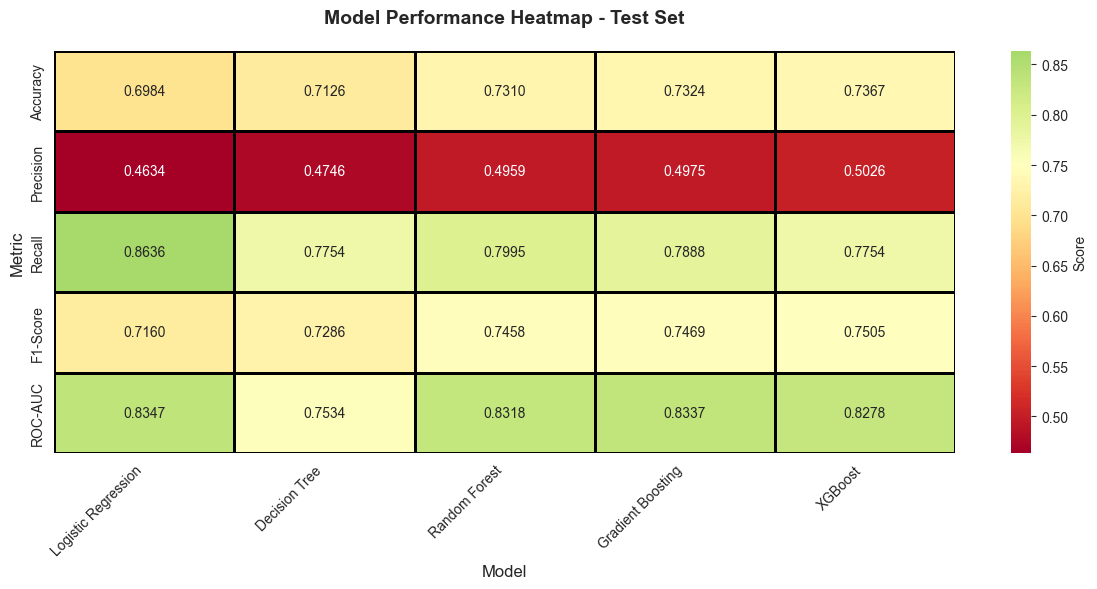

 Performance heatmap created!


In [157]:
# Create heatmap for model comparison
plt.figure(figsize=(12, 6))

heatmap_data = test_metrics.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]

sns.heatmap(heatmap_data.T, annot=True, fmt='.4f', cmap='RdYlGn', 
            center=0.75, linewidths=1, linecolor='black', 
            cbar_kws={'label': 'Score'})

plt.title('Model Performance Heatmap - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(" Performance heatmap created!")

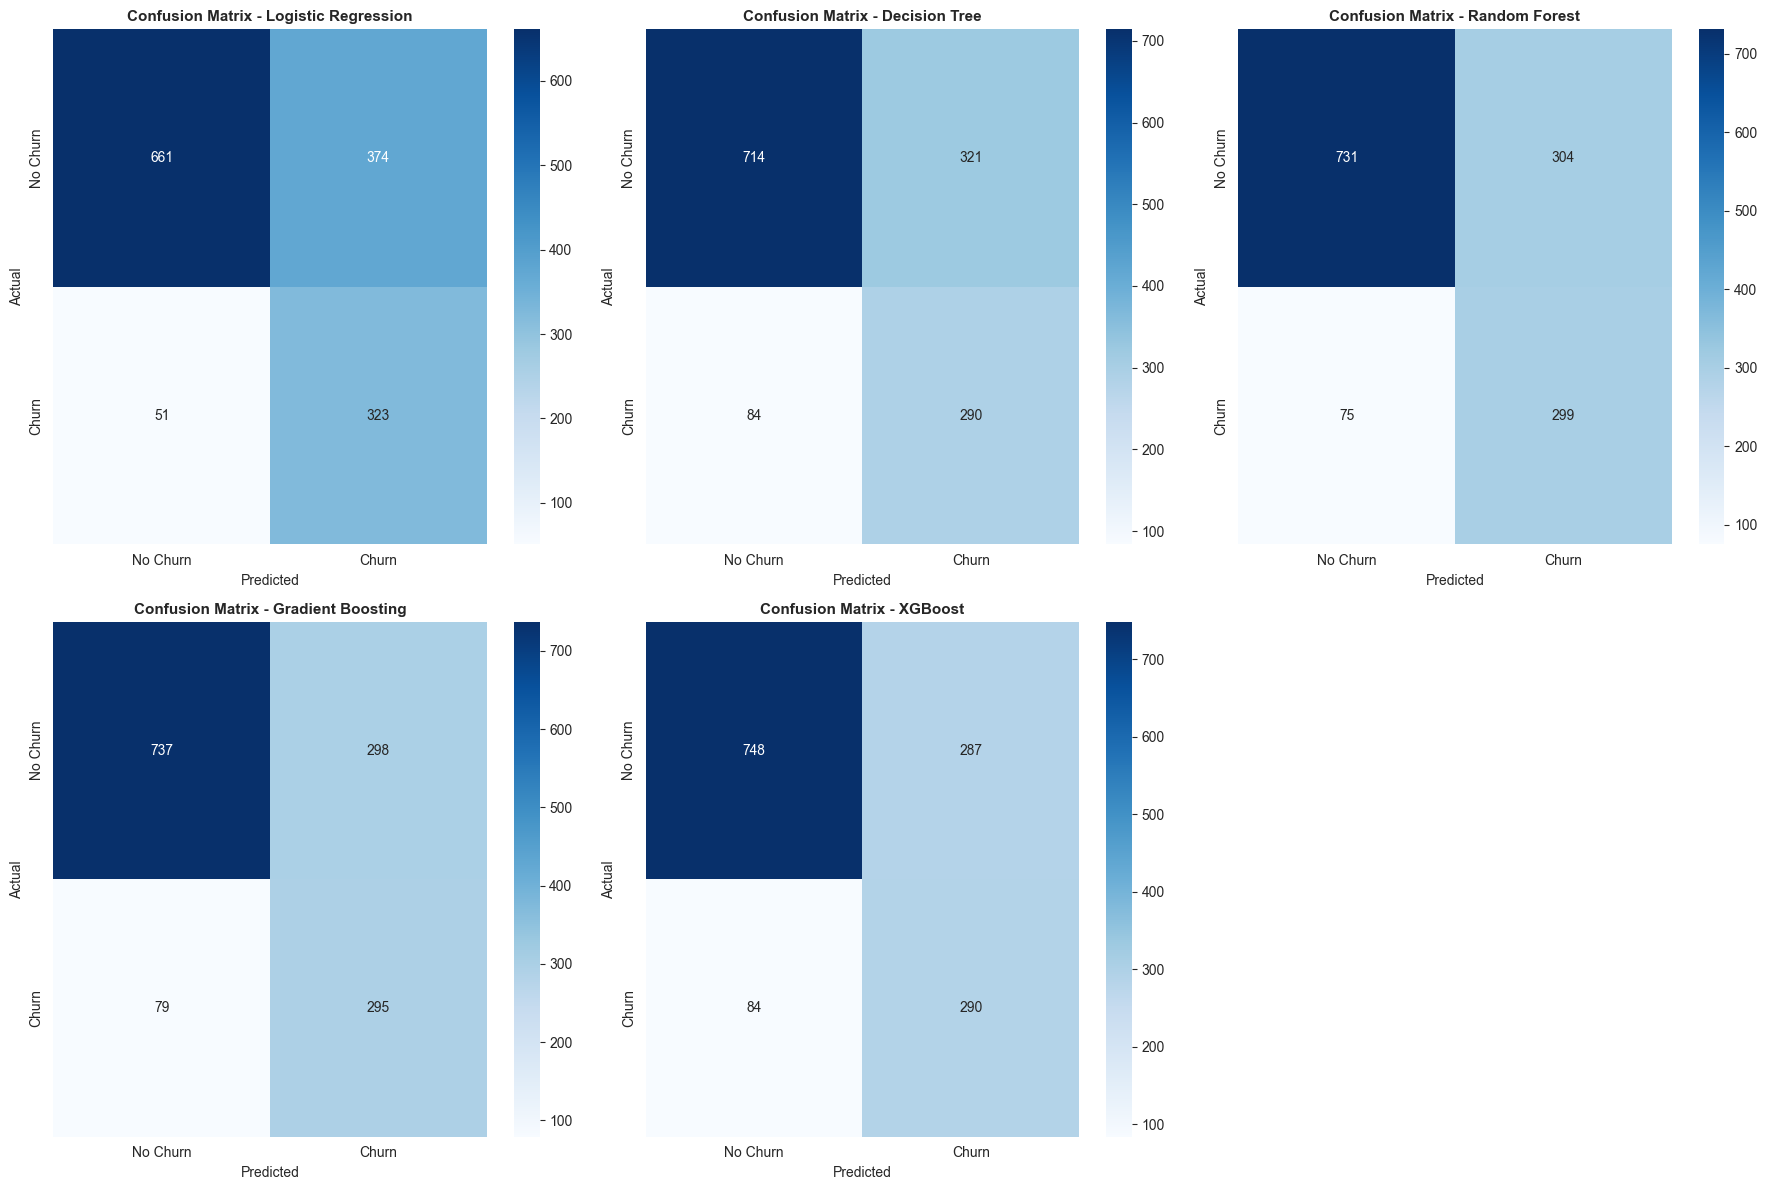

 Confusion matrices for all models displayed!


In [158]:
# Display confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i in range(len(list(models))):
    model_name = list(models.keys())[i]
    model = list(models.values())[i]
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=axes[i], cbar=True)
    
    axes[i].set_title(f'Confusion Matrix - {model_name}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

print(" Confusion matrices for all models displayed!")

In [159]:
from xgboost import XGBClassifier

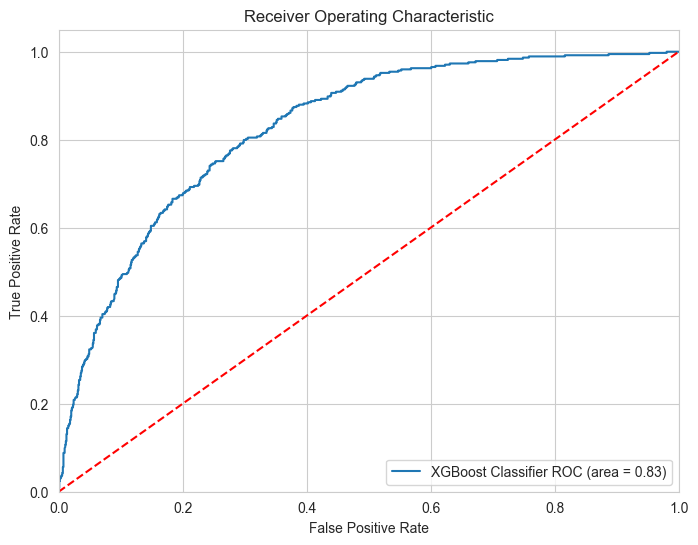

In [160]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from xgboost import XGBClassifier

plt.figure(figsize=(8,6))

# List of models
auc_models = [
    {
        'label': 'XGBoost Classifier',
        'model': XGBClassifier(random_state=42, n_estimators=100, max_depth=5, eval_metric='logloss')
    }
]

for algo in auc_models:
    model = algo['model']
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict probabilities
    y_scores = model.predict_proba(X_test_scaled)[:, 1]
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    
    # Compute AUC dynamically
    auc_score = roc_auc_score(y_test, y_scores)
    
    # Plot
    plt.plot(fpr, tpr, label=f"{algo['label']} ROC (area = {auc_score:.2f})")

# Random classifier
plt.plot([0, 1], [0, 1], 'r--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


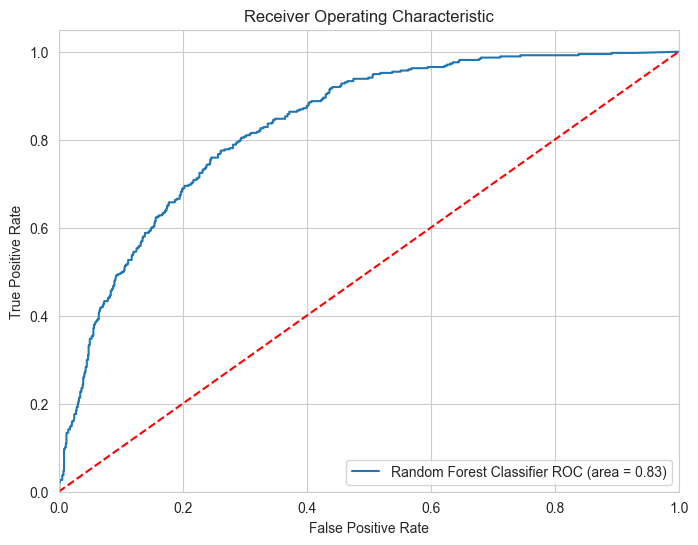

In [161]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from xgboost import XGBClassifier

plt.figure(figsize=(8,6))

# List of models
auc_models = [
    {
        'label': 'Random Forest Classifier',
        'model': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
    }
]

for algo in auc_models:
    model = algo['model']
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict probabilities
    y_scores = model.predict_proba(X_test_scaled)[:, 1]
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    
    # Compute AUC dynamically
    auc_score = roc_auc_score(y_test, y_scores)
    
    # Plot
    plt.plot(fpr, tpr, label=f"{algo['label']} ROC (area = {auc_score:.2f})")

# Random classifier
plt.plot([0, 1], [0, 1], 'r--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [162]:
import joblib

# Save Random Forest
joblib.dump(models["Random Forest"], "random_forest_model.pkl")

# Save XGBoost
joblib.dump(models["XGBoost"], "xgboost_model.pkl")

print("Models saved successfully!")


Models saved successfully!


## SHAP ANALYSIS

In [163]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

print("SHAP libraries loaded successfully!")

SHAP libraries loaded successfully!


In [164]:
print("\nLoading saved XGBoost model")
model = joblib.load("xgboost_model.pkl")
print(f"Model loaded: {type(model).__name__}")

# X_train_scaled, X_test_scaled, y_test already exist in memory
print(f"Training data shape: {X_train_scaled_df.shape}")
print(f"Test data shape: {X_test_scaled_df.shape}")


Loading saved XGBoost model
Model loaded: XGBClassifier
Training data shape: (5634, 19)
Test data shape: (1409, 19)


In [165]:
print("\nInitializing SHAP TreeExplainer")
explainer = shap.TreeExplainer(model)
print("Explainer initialized!")


Initializing SHAP TreeExplainer
Explainer initialized!


In [166]:
print("\nCalculating SHAP values for test data")
shap_values = explainer.shap_values(X_test_scaled_df)

print("SHAP calculation completed!")
print("SHAP shape:", np.array(shap_values).shape)


Calculating SHAP values for test data
SHAP calculation completed!
SHAP shape: (1409, 19)



Creating SHAP Feature Importance plot


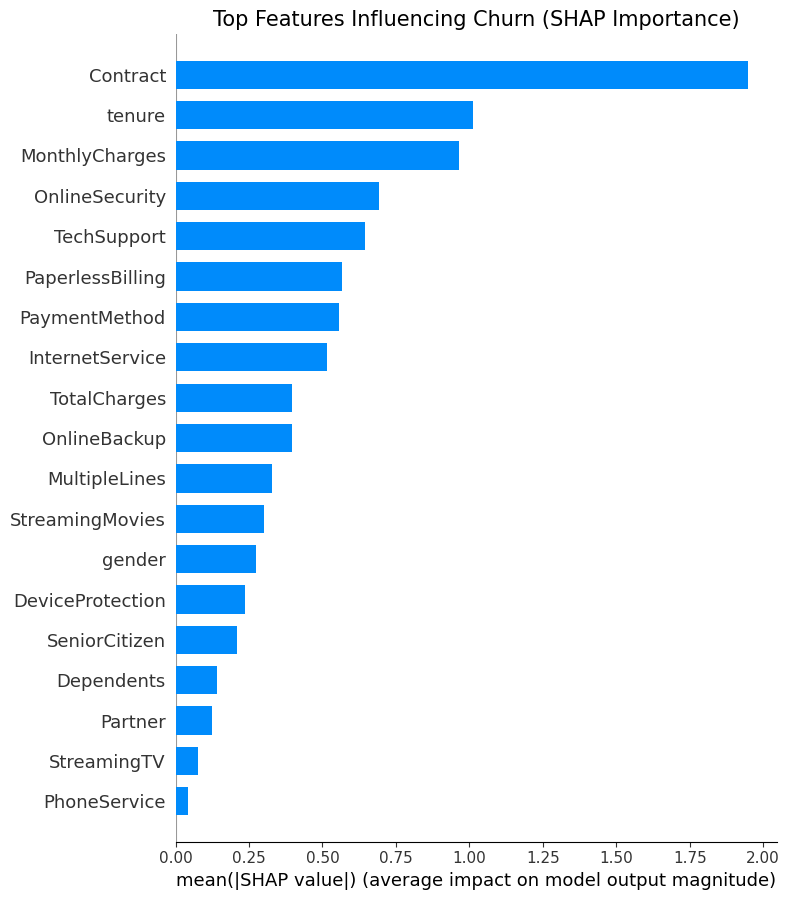

In [167]:
print("\nCreating SHAP Feature Importance plot")

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar", show=False)
plt.title("Top Features Influencing Churn (SHAP Importance)", fontsize=15)
plt.tight_layout()
plt.show()


Creating SHAP summary beeswarm plot


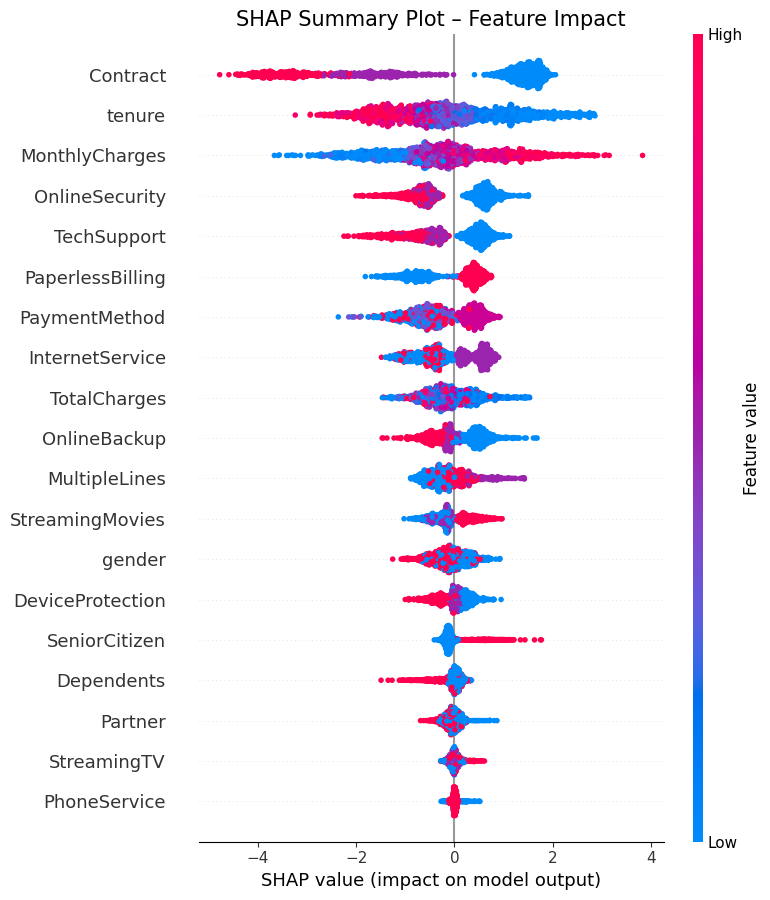

In [168]:
print("\nCreating SHAP summary beeswarm plot")

plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.title("SHAP Summary Plot – Feature Impact", fontsize=15)
plt.tight_layout()
plt.show()

In [169]:
feature_importance = pd.DataFrame({
    "Feature": X_test_scaled_df.columns,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values("Mean_SHAP", ascending=False)

print("\nTop 10 most important churn drivers:")
print(feature_importance.head(10))


Top 10 most important churn drivers:
             Feature  Mean_SHAP
14          Contract   1.950054
4             tenure   1.011245
17    MonthlyCharges   0.964683
8     OnlineSecurity   0.690717
11       TechSupport   0.644269
15  PaperlessBilling   0.566529
16     PaymentMethod   0.556043
7    InternetService   0.516337
18      TotalCharges   0.397507
9       OnlineBackup   0.396337



Creating dependence plots for: ['Contract', 'tenure', 'MonthlyCharges']


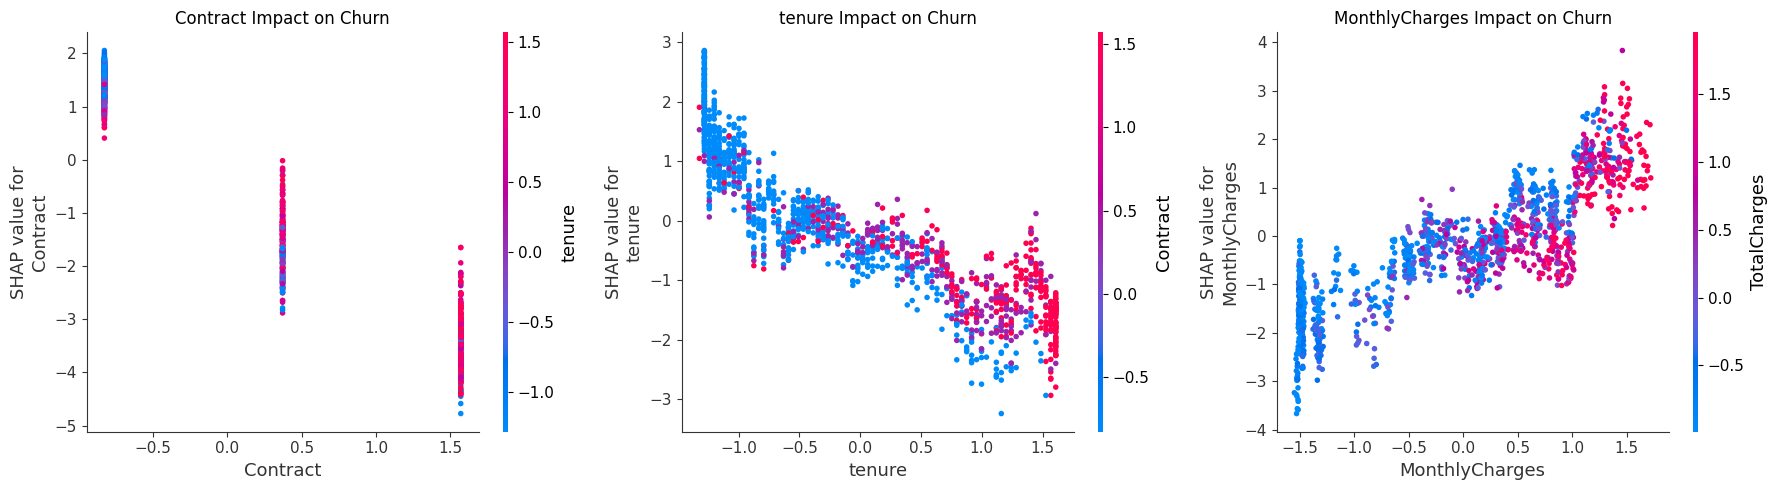

In [170]:
top_3 = feature_importance.head(3)["Feature"].tolist()
print("\nCreating dependence plots for:", top_3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(top_3):
    shap.dependence_plot(feature, shap_values, X_test_scaled_df, ax=axes[i], show=False)
    axes[i].set_title(f"{feature} Impact on Churn")

plt.tight_layout()
plt.show()



Generating waterfall plot for high-risk customer...


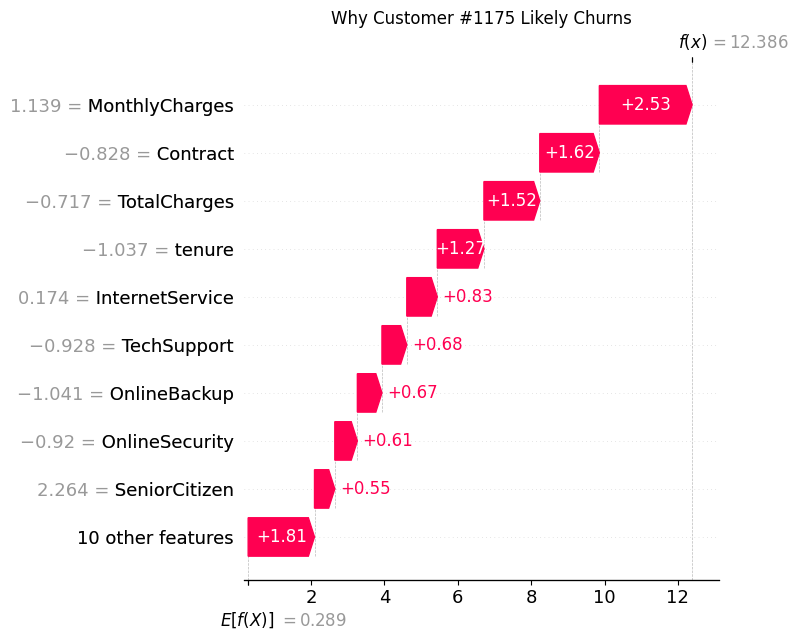

In [171]:
print("\nGenerating waterfall plot for high-risk customer...")

y_pred_proba = model.predict_proba(X_test_scaled_df)[:, 1]
high_risk_index = np.argmax(y_pred_proba)

explanation = shap.Explanation(
    values=shap_values[high_risk_index],
    base_values=explainer.expected_value,
    data=X_test_scaled_df.iloc[high_risk_index],
    feature_names=X_test_scaled_df.columns
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(explanation, max_display=10, show=False)
plt.title(f"Why Customer #{high_risk_index} Likely Churns")
plt.tight_layout()
plt.show()

### Simple explanation:
### Customer #34 is predicted to churn because:
### They are on month-to-month contract
### They have low tenure
### They do not have security/backup services
### They pay in a risky payment mode


Creating force plot...


<Figure size 1500x300 with 0 Axes>

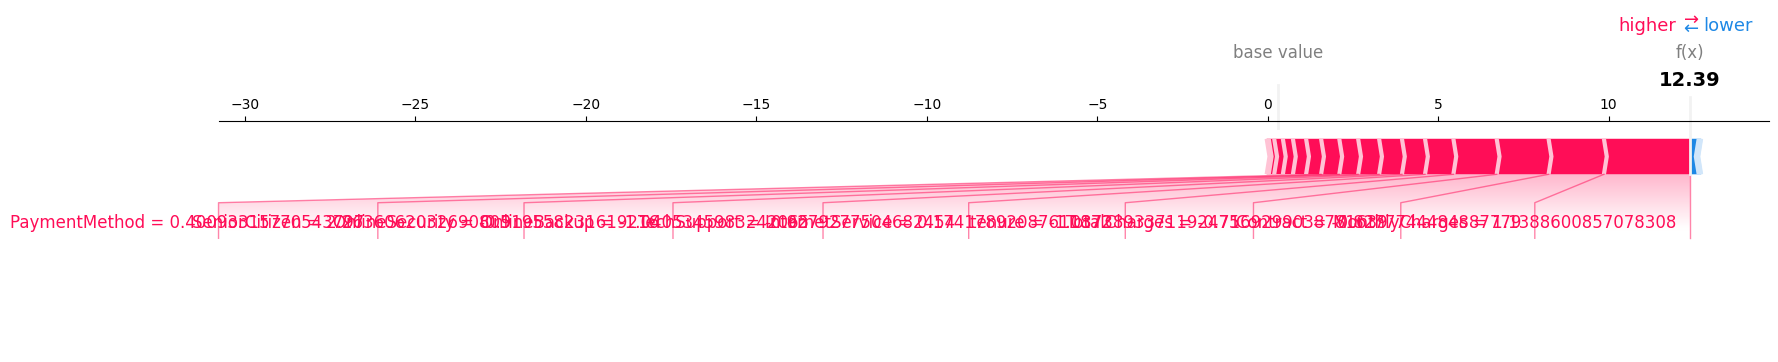


SHAP Analysis Completed Successfully!


In [172]:
print("\nCreating force plot...")

plt.figure(figsize=(15, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_index],
    X_test_scaled_df.iloc[high_risk_index],
    matplotlib=True,
    show=False
)
plt.show()

print("\nSHAP Analysis Completed Successfully!")